# Fraud Detection Project

### Install Python Modules

In [1]:
#!pip install pandas numpy scikit-learn matplotlib seaborn lime

### Install lime in Annaconda Kernel

In [2]:
#%pip install lime

### Import Modules

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, roc_auc_score, f1_score, 
                             precision_score, recall_score)
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [4]:
df = pd.read_csv('creditcard.csv')

In [5]:
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Checking Data quality

In [7]:
print("Missing Values:",df.isnull().sum().sum())
print("Data types:\n", df.dtypes)
print("Summary statistics:\n", df.describe())

Missing Values: 0
Data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Summary statistics:
                 Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.8325

### Analyse Class distribution

In [8]:
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)
#counts = df['Class'].value_counts()

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### Visualise Class Imbalance

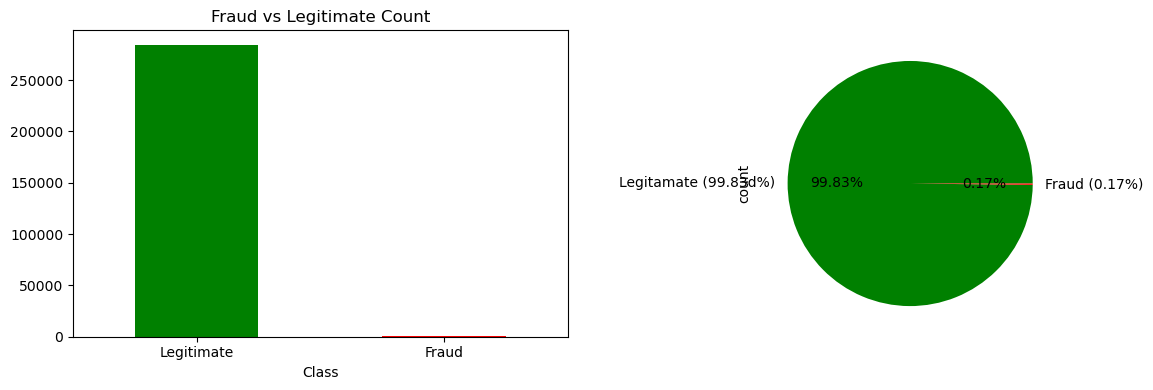

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Count plot
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Fraud vs Legitimate Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

#Pie Chart
df['Class'].value_counts().plot(kind='pie', ax=axes[1], labels=['Legitamate (99.83d%)', 'Fraud (0.17%)'], autopct='%1.2f%%', colors=['green', 'red'])

plt.tight_layout()
plt.show()


### Analyse Transaction Amounts

In [10]:
print("Legitimate Transactions Amount Statistics:")
print(df[df['Class']==0]['Amount'].describe())
print("\nFraudulent Transactions Amount Statistics:")
print(df[df['Class']==1]['Amount'].describe())


Legitimate Transactions Amount Statistics:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transactions Amount Statistics:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


### Feature Correlation

In [11]:
correlation = df.corr()['Class'].sort_values(ascending=False)
print("Top features correlated with Fraud")
print(correlation.head(10))

Top features correlated with Fraud
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


## Data Preprocessing

#### Seperate Features and Target

In [12]:
# Features
X = df.drop('Class', axis =1)
# Target
y = df['Class']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


#### Train Test Split (Critical Split Before Scaling)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Train fraud ratio:", y_train.sum() / len(y_train))
print("Test fraud ratio:", y_test.sum() / len(y_test))
    

Training set size: 227845
Test set size: 56962
Train fraud ratio: 0.001729245759178389
Test fraud ratio: 0.0017204452090867595


### Scale Ffeatures(FIT ON TRAINING ONLY)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean:", X_train_scaled.mean())
print("Scaled training data std:", X_train_scaled.std())

Scaled training data mean: -6.661191966396339e-18
Scaled training data std: 1.0


### Convert to DataFrame

In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

## Train Models

### Create Evaluation Function

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"\n{name}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    return {'name': name, 
            'precision': precision, 
            'recall': recall, 
            'f1': f1, 
            'roc_auc': roc_auc, 
            'model': model, 
            'predictions': y_pred, 
            'probabilities': y_proba
            }
    

### Train Logistic Regression

In [17]:
print("Training Logistic Regression")
lr_result = evaluate_model(
    LogisticRegression(class_weight = 'balanced', max_iter = 1000),
    X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression"
)
    

Training Logistic Regression

Logistic Regression
Precision: 0.0610
Recall: 0.9184
F1-Score: 0.1144
ROC-AUC: 0.9721


### Train Decision Tree

In [18]:
print("\nTraining Decision Tree....")
dt_result = evaluate_model(
    DecisionTreeClassifier(
        class_weight='balanced',
        max_depth = 10
    ),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Decision Tree"
)
    
                           


Training Decision Tree....

Decision Tree
Precision: 0.1318
Recall: 0.7857
F1-Score: 0.2258
ROC-AUC: 0.8915


### Train Random Forest

In [19]:
print("\nTraining Random Forest...")
rf_result = evaluate_model(
    RandomForestClassifier(
        n_estimators = 100,
        class_weight = 'balanced',
        max_depth = 15,
        n_jobs = -1
    ),
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    "Random Forest"
)
    


Training Random Forest...

Random Forest
Precision: 0.8667
Recall: 0.7959
F1-Score: 0.8298
ROC-AUC: 0.9540


### Train SVM

In [20]:
print("\nTraining Support Vector Machine..")
svm_result = evaluate_model(
    SVC(kernel = 'rbf', probability = True, class_weight = 'balanced', cache_size=40000, verbose=True),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Support Vector Machine"
)



Training Support Vector Machine..
[LibSVM].....*..*
optimization finished, #iter = 7446
obj = -1899.768305, rho = 0.876115
nSV = 4603, nBSV = 2713
Total nSV = 4603
.....*..*
optimization finished, #iter = 7154
obj = -1724.827654, rho = 0.862866
nSV = 4370, nBSV = 2442
Total nSV = 4370
.....*..*
optimization finished, #iter = 7186
obj = -1847.410736, rho = 0.867712
nSV = 4539, nBSV = 2676
Total nSV = 4539
.....*..*
optimization finished, #iter = 7018
obj = -1804.151778, rho = 0.873866
nSV = 4431, nBSV = 2578
Total nSV = 4431
....*..*
optimization finished, #iter = 6450
obj = -1335.004848, rho = 0.891614
nSV = 3748, nBSV = 1919
Total nSV = 3748
......*..*
optimization finished, #iter = 8684
obj = -2332.756944, rho = -0.880991
nSV = 5524, nBSV = 3607
Total nSV = 5524

Support Vector Machine
Precision: 0.3217
Recall: 0.7551
F1-Score: 0.4512
ROC-AUC: 0.9732


## Compare Models

### Create Comparision Table

In [21]:
results_list = [lr_result, dt_result, rf_result, svm_result]
comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }
    for r in results_list
])

print("\nModel Comparison:")
print(comparison_df.to_string())




Model Comparison:
                    Model  Precision    Recall  F1-Score   ROC-AUC
0     Logistic Regression   0.060976  0.918367  0.114358  0.972083
1           Decision Tree   0.131849  0.785714  0.225806  0.891475
2           Random Forest   0.866667  0.795918  0.829787  0.954036
3  Support Vector Machine   0.321739  0.755102  0.451220  0.973191


### Visualise Confusion Matrices

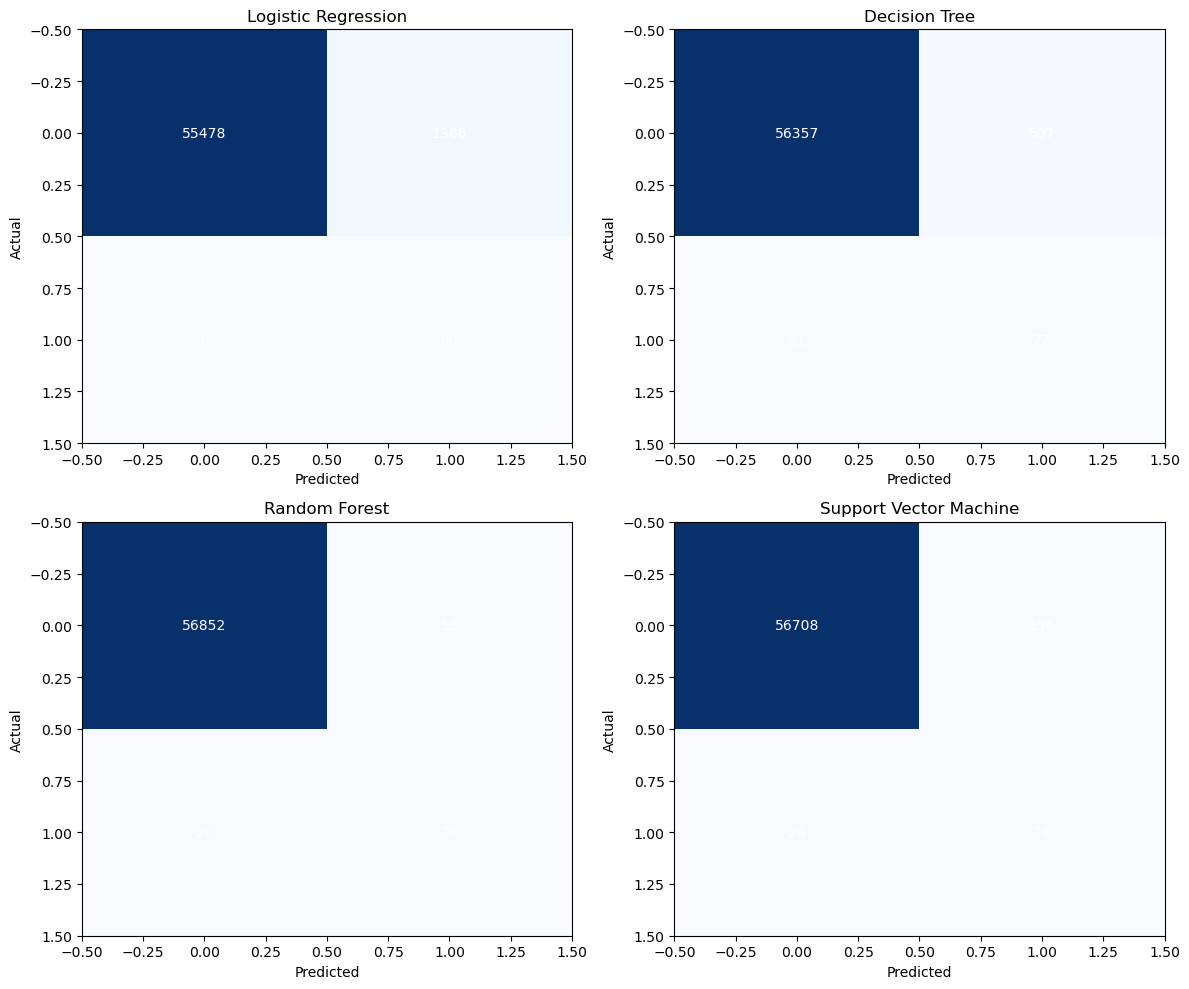

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, result in enumerate(results_list):
    cm = confusion_matrix(y_test, result['predictions'])
    axes[idx].imshow(cm, cmap = 'Blues', aspect = 'auto')
    axes[idx].set_title(result['name'])
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, cm[i, j], ha = 'center', va = 'center', color = 'white')

plt.tight_layout()
plt.show()
    

### Plot ROC Curves

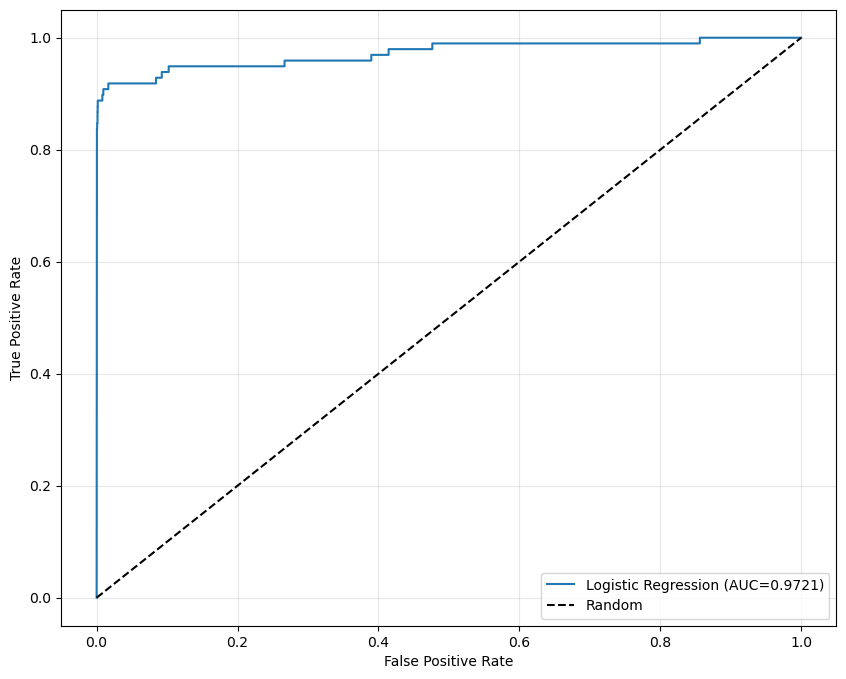

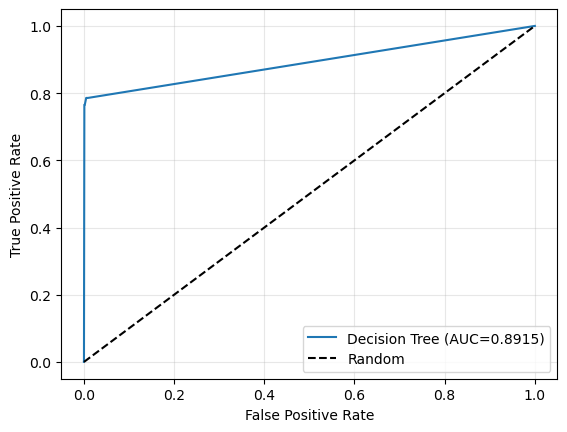

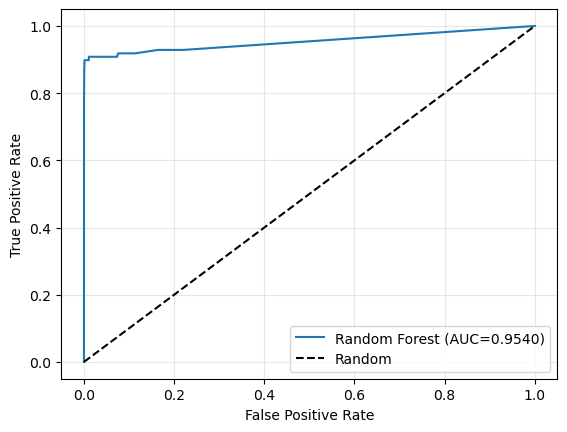

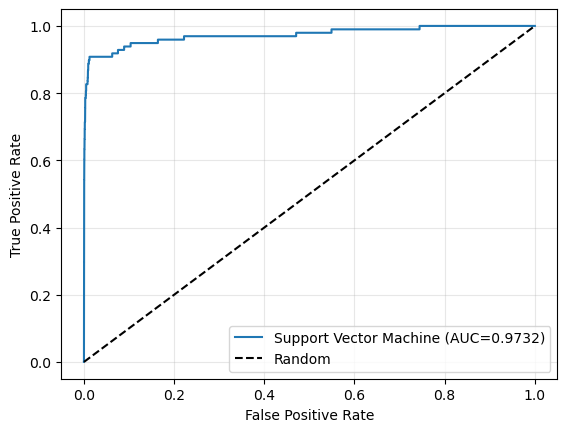

In [23]:
plt.figure(figsize=(10, 8))

for result in results_list:
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    plt.plot(fpr, tpr, label=f"{result['name']} (AUC={result['roc_auc']:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Hyperparameter Tuning

### Tune Random Forest(Best Model)

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(
    
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    pre_dispatch='1*n_jobs', # Limits memory duplication
    verbose=10
)

print("Starting Grid Search (this takes 5-10 minutes)...")
grid_search.fit(X_train_scaled, y_train)



Starting Grid Search (this takes 5-10 minutes)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 2/5; 2/24] START max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=200
[CV 2/5; 2/24] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=200;, score=0.844 total time= 2.3min
[CV 4/5; 4/24] START max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200
[CV 4/5; 4/24] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200;, score=0.827 total time= 2.2min
[CV 3/5; 7/24] START max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100
[CV 3/5; 7/24] END max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100;, score=0.808 total time= 1.1min
[CV 1/5; 9/24] START max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100
[CV 1/5; 9/24] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100;, score=0.831 total time= 1.1min
[CV 1/5; 10/24] 

KeyboardInterrupt: 

In [ ]:
print(f"Best parameters: {grid_search.best_params_:.4f}")
print(f"Best F1-Score (CV): {grid_search.best_score_:.4f}")

#Evaluate on test set

y_pred_tuned = grid_search.predict(X_test_scaled)
y_proba_tuned = grid_search.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}") 
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")


## Feature Importance

### Extract Feature Importance

In [ ]:
best_model = grid_search.best_estimator_fefature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_}).sort_values('Importance', ascending=False)

print("Top 15 Features:")
print(feature_importance.head(15))

### Visualise Feature Importance

In [ ]:
plt.figure(figsize=(10, 8))

top_n = 15
top_features = feature_importance.head(top_n)

plt.barh(range(top_n), top_features['Importance'])
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Important Score')
plt.title(f'Top {top_n} Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## LIME Explanations

### Initialize LIME Explainer

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled.values,
    feature_names=X.columns.tolist(),
    class_names=['Legitimate', 'Fraud'],
    mode='classification'
)

### Explain Fradulent Transactions

In [ ]:
# Find Fraud Examples
fraud_indices = y_test[y_test == 1].index.tolist()

print("Explaining 3 Fradulent Transactionss:\n")

for i in range(3):
    fraud_idx = fraud_indices[i]
    fraud_instance = X_test_scaled.loc[fraud_idx].values

    explaination = explainer.explain_instance(
        fraud_instance,
        best_model.predict_proba,
        num_features = 10
    )
    pred_fraud_prob = best_model.predict_proba([fraud_instance]}[0, 1]

    print(f"\nFraud Transaction {i+1}")
    print(f"Fraud Probabibilty: {pred_fraud_prob:.2%}")
    print("Top Contributing Features:")

    for feature, weight in explanation.as_list()[:5]:
        print(f" {feature}: {weight:.4f}")

### Explain Legitimate Transactions

In [ ]:
# Find legitimate examples
legit_indices = y_test[y_test == 0].index.tolist()

print("\nExplaining 3 Legitimates Transactions:\n")
for i in range(3):
    legit_idx = legit_indices[i*1000]
    legit_instance = X_test_scaled.loc[legit_idx].values

    explanation = explainer.explain_instance(
        legit_instance,
        best_model.predict_proba,
        num_features = 10
    )

    pred_fraud_prob = best_model.predict_proba([legit_instance])[0, 1]

    print(f"\nLegitimate Transaction {i+1}")
    print(f"Fraud Probability: {pred_fraud_prob:.2%}")

    print("Top Contributing Features:")

    for featueres, weight in explanation.as_list()[:5]:
        print(f" {features}: {weight:.4f}")
    

[CV 4/5; 2/24] START max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=200
[CV 4/5; 2/24] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=200;, score=0.827 total time= 2.3min
[CV 5/5; 4/24] START max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200
[CV 5/5; 4/24] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200;, score=0.834 total time= 2.3min
[CV 5/5; 7/24] START max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100
[CV 5/5; 7/24] END max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100;, score=0.844 total time= 1.2min
[CV 2/5; 9/24] START max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100
[CV 2/5; 9/24] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100;, score=0.853 total time= 1.1min
[CV 2/5; 10/24] START max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=200
[CV 2/5; 10/24] END max_depth=15, 

## Summary and Conclusions

### Generate Summary Report